# <center> Анализ лояльности и оттока клиентов банка

Предварительная подготовка данных, загрузка необходимых файлов, библиотек, очистка лишних данных

In [69]:
import pandas as pd 
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
churn_data = pd.read_csv('data/churn.csv')
churn_data=churn_data.drop(columns=['RowNumber'],axis=1)

### <center> Оглавление
 1.1 Соотношение ушедших и лояльных клиентов 

 1.2 Распределение баланса пользователей, у которых на счету больше 2 500 долларов

 1.3 распределение баланса клиента в разрезе признака оттока

 1.4 распределение возраста в разрезе признака оттока

 1.5 взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты

 1.6 Кто чаще уходит, мужчины или женщины?

 1.7 Как отток клиентов зависит от числа приобретённых у банка услуг

 1.8 Как влияет наличие статуса активного клиента на отток клиентов

 1.9 В какой стране доля ушедших клиентов больше

 1.10 Создание нового признака кредитного потенциала клиента. Оценка лояльности по этому признаку
 

### 1.1 Соотношение ушедших и лояльных клиентов

([<matplotlib.patches.Wedge at 0x2896957aed0>,
 [Text(-0.8823431426537007, 0.6568642010431011, 'Лояльные'),
  Text(0.8823431426537006, -0.6568642010431012, 'Ушедшие')],
 [Text(-0.48127807781110943, 0.3582895642053278, '79.6%'),
  Text(0.4812780778111093, -0.35828956420532787, '20.4%')])

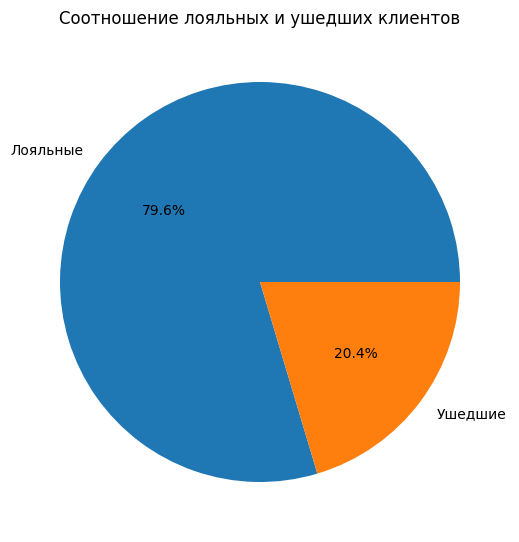

In [83]:
churn_tmp=churn_data.copy()
churn_tmp=churn_tmp['Exited'].value_counts()
churn_tmp.rename(index={1:'Ушедшие',0:'Лояльные'},inplace=True)
fig=plt.figure(figsize=(5,5))
axes=fig.add_axes([0,0,1,1])
axes.set_title('Соотношение лояльных и ушедших клиентов')
axes.pie(
    churn_tmp, 
    labels=churn_tmp.index,
    autopct='%.1f%%')

Из диаграммы видно, что количество ушедших клиентов составляет примерно 20% от общего количества клиентов и 25% от количества лояльных клиентов

### 1.2 Распределение баланса пользователей, у которых на счету больше 2 500 долларов

In [ ]:
churn_tmp=churn_data.copy()
churn_tmp=churn_tmp[churn_tmp['Balance']>2500]
fig = px.box(
    data_frame=churn_tmp,
    x='Balance',
    height=400,width=800,
    title='Распределение баланса пользователей, у которых на счету больше 2 500 долларов')
fig.show()

##### Анализ:
##### Минимальный баланс: 3768.69
##### Максимальный:       250898.1
##### В основном баланс таких клиентов находится в диапазоне от 100 000 до 139 520 с квантилями от 41 299 до 198 338
##### Среднее значение таких вкладов: 119 839
##### Все выше указанное позволяет сделать вывод, что количество клиентов с суммами менее 2500 будет незначительным 
##### и не будет влиять на статистические показатели банка. При необходимости можно сделать более развернутый анализ, 
##### сравнив количество клиентов банка по текущей выборке и количество клиентов, не вошедших в выборку, и сравнить 
##### суммарную сумму на счетах, но исходных данных вполне достаточно для анализа. 

### 1.3 распределение баланса клиента в разрезе признака оттока

([<matplotlib.patches.Wedge at 0x289596f6890>,
 [Text(-0.7955841542734882, 0.7596353424301285, 'Лояльные'),
  Text(0.7955841187123908, -0.7596353796741097, 'Ушедшие')],
 [Text(-0.4339549932400844, 0.4143465504164337, '75.7%'),
  Text(0.4339549738431222, -0.41434657073133246, '24.3%')])

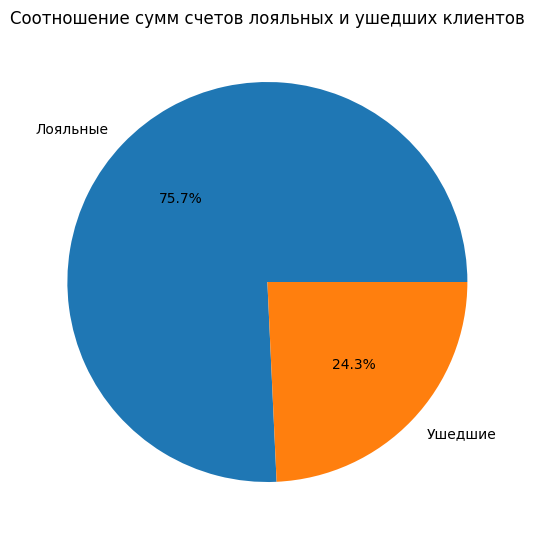

In [ ]:
churn_tmp=churn_data.copy()
churn_tmp=churn_tmp.groupby(by='Exited',as_index=False)['Balance'].sum()
churn_tmp.rename(index={1:'Ушедшие',0:'Лояльные'},inplace=True)
fig=plt.figure(figsize=(5,5))
axes=fig.add_axes([0,0,1,1])
axes.set_title('Соотношение сумм счетов лояльных и ушедших клиентов')
axes.pie(
    churn_tmp['Balance'], 
    labels=churn_tmp.index,
    autopct='%.1f%%')

##### Судя по диаграмме ушедшие клиенты относятся к категории клентов с суммами на счете выше среднего. Если применить разницу между количеством клиентов (будем округлять до целых чисел) 20% и суммами на их счетах 24%, то получается что 4% по отношению к 20 это тоже в свою очередь 20%. Значит банк недостаточно внимания уделяет сегменту клиентов, сумма на счетах которых находится в промежутке медианы и верхнего квантиля (см. задание 1.2)

### 1.4 распределение возраста в разрезе признака оттока

In [ ]:
churn_tmp=churn_data.copy()
churn_tmp=churn_tmp[churn_tmp['Exited']==1]
churn_1_4=churn_tmp.groupby(by='Age',as_index=False)['Exited'].sum()
fig = px.histogram(
    data_frame=churn_tmp,
    x='Age',
    y='Exited',
    height=400,width=800, facet_col_wrap=10,
    title='Распределение ушедших клиентов по возрасту')
fig.show()

#### Анализ: значительная часть ушедших клиентов - люди среднего возраста от 40 до 49 лет (809 клиентов). Также следует обратить внимание на возрастные группы 30-39 и 50-59 лет (473 и 487 клиентов соответственно), где количество ушедших клиентов тоже значительно. А если совместить этот анализ с анализом в задании 1.3, мы получим картину, что основной контингент клиентов, покидающих банк - это успешные люди среднего возраста.

### 1.5 взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты

In [ ]:
churn_tmp=churn_data.copy()
churn_tmp=churn_tmp.groupby(by='CreditScore',as_index=False)['EstimatedSalary'].mean()
fig = px.line(
    data_frame=churn_tmp,
    x='CreditScore',
    y='EstimatedSalary',
    height=400,width=800, facet_col_wrap=10,
    title='Взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты')
fig.show()

#### Анализ: явной зависимости между кредитным рейтингом и зарплатой не наблюдается, единственное что можно заметить, что люди со средней зарплатой (около 100 k) совокупно имеют более стабильные показатели кредитного рейтинга без аномальных отклонений, а у людей с очень большой или очень низкой зарплатой прогнозировать кредитный рейтинг по этому показателю нет возможности

###  1.6 Кто чаще уходит, мужчины или женщины?

([<matplotlib.patches.Wedge at 0x28961eb8210>,
 [Text(-0.35216690991224814, 1.042102906417048, 'Женщины'),
  Text(0.352167007480962, -1.0421028734447977, 'Мужчины')],
 [Text(-0.19209104177031713, 0.5684197671365716, '60.4%'),
  Text(0.19209109498961563, -0.5684197491517078, '39.6%')])

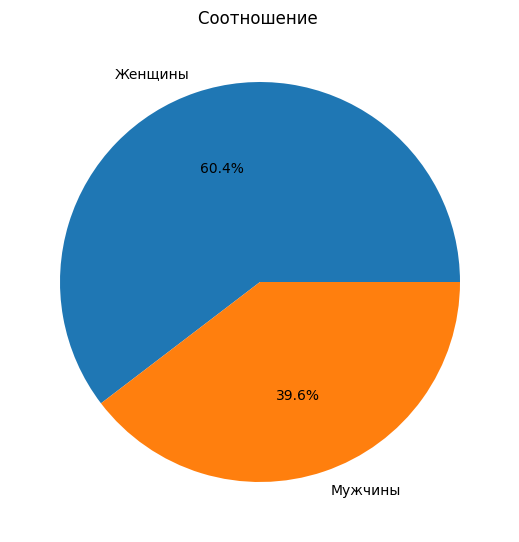

In [ ]:
churn_tmp=churn_data.copy()
churn_tmp=churn_tmp.groupby(by='Gender',as_index=False)['Exited'].mean()
churn_tmp.rename(index={1:'Мужчины',0:'Женщины'},inplace=True)
fig=plt.figure(figsize=(5,5))
axes=fig.add_axes([0,0,1,1])
axes.set_title('Соотношение ')
axes.pie(
    churn_tmp['Exited'], 
    labels=churn_tmp.index,
    autopct='%.1f%%')

#### График явно указывает, что основной контингент ушедших клиентов составляют женщины. Ну возможно это был банк Харви Ванштейна))

### 1.7 Как отток клиентов зависит от числа приобретённых у банка услуг

In [82]:
churn_tmp=churn_data.copy()
churn_tmp=churn_tmp.groupby(by=['NumOfProducts','Exited'],as_index=False)['Exited'].value_counts()
fig = px.bar(
    data_frame=churn_tmp,
    x='NumOfProducts',
    y='count',
    pattern_shape='Exited',
    title='Зависимость оттока клиентов от количества услуг'
)
fig.show()

#### Исходя из графика выходит, что оптимальное количество услуг банка - 2 при этом процент ушедших клиентов минимален. При одной услуге он растет, при трех - уход клиента практически неизбежен, при 4 доля ушедших клиентов составила 100%. Возможно, что услуги для клиентов категории VIP непривлекательны, что и ведет к массовому оттоку клиентов с большим набором услуг. Вместе с тем добавление к существующей еще одной услуги может существенно сократить отток клиентов (обычно для банков это кредитная карта)

### 1.8 Как влияет наличие статуса активного клиента на отток клиентов

In [81]:
churn_tmp=churn_data.copy()
churn_tmp=churn_tmp.groupby(by=['IsActiveMember','Exited'],as_index=False)['Exited'].value_counts()
fig = px.bar(
    data_frame=churn_tmp,
    x='IsActiveMember',
    y='count',
    pattern_shape='Exited',
    title='Зависимость оттока клиентов от статуса',
 )
fig.show()

#### При сопоставимых показателях активных и неактивных пользователей, отток активных пользователей примерно в два раза ниже, чем у неактивных. Перед рекомендацией интересно бы узнать, что вложено в понятие активности пользователя? Это тот, кто активно работает со счетом? Или тот кто охотно откликается на различные маркетинговые мероприятия от банка? В первом случае рекомендовалось бы снизить тарифы на услуги, ввести более гибкую политику тарифов при пополнении и снятии денежных средств, программы кешбека, во втором - привлечь в активных клиенты за счет проведения дополнительных маркетинговых акций. 

###  1.9 В какой стране доля ушедших клиентов больше

In [ ]:
churn_tmp=churn_data.copy()

churn_tmp=churn_tmp.groupby(by='Geography',as_index=False)['Exited'].mean()
#churn_tmp=churn_tmp[churn_tmp['Exited']==1]
fig = px.choropleth(
    data_frame=churn_tmp,
    locations="Geography",
    locationmode = "country names",
    color='Exited',
    title='Зависимость оттока клиентов от страны',
    range_color=[0, 0.4],
    width=800, #ширина
    height=500, #высота
    color_continuous_scale='Blues'
)
fig.show()

,Geography,Exited
0,France,0.161548
1,Germany,0.324432
2,Spain,0.166734


#### Из графика очевидно, что наибольшая доля ушедших клиентов в Германии. Причин может быть множество. Например в германии заработал национальный а не транснациональный банк, ориентированный именно на жителей этой страны, их менталитет, привычки, обычаи. Или в германии начался экономический кризис. С  учетом всех выше приведенных графиков, типичный клиент ушедший из банка, это женщина, немка, средних лет (от 30 до 40), с предполагаемым уровнем дохода выше среднего (от 100 000 до 140 000), стабильным кредитным рейтингом, не пользующаяся дополнительными услугами банка кроме собственно счета, просто держащая деньги на счете (не активный клиент банка)

###  1.10 Создание нового признака кредитного потенциала клиента. Оценка лояльности по этому признаку

Text(0.5, 1.0, 'Зависимость оттока клиентов от кредитного рейтинга')

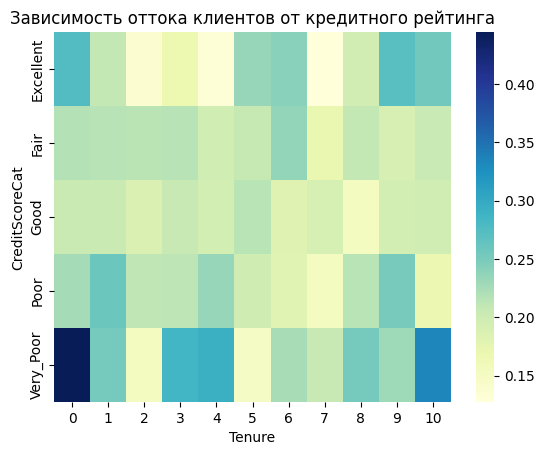

In [84]:
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"
churn_tmp=churn_data.copy()
churn_tmp['CreditScoreCat']=churn_tmp['CreditScore'].agg(get_credit_score_cat)
churn_tmp=churn_tmp.pivot_table(
    index='CreditScoreCat',
    columns='Tenure',
    values='Exited',
    aggfunc='mean'
)
heatmap = sns.heatmap(data=churn_tmp, cmap='YlGnBu')
heatmap.set_title('Зависимость оттока клиентов от кредитного рейтинга')

#### Чаще всего уходят клиенты с низким кредитным рейтингом, являющиеся клиентами менее года. Также достаточно часто уходят клиенты с низким кредитным рейтингом и являющиеся клиентами банка 10 лет